In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import evaluation
import OT
import poincare
from data import *
from data_utils import *

/home/onyxia/work/OT_simulation_maladies/HGCN/data.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


2
3


In [2]:
# Seuils calcul de la courbe PR
seuils = np.linspace(0, 1., 30)

# Valeurs de tau à tester
taus = [0., 0.5, 0.7, 0.8, 0.9, 0.95, 1.]

## Analyse de la représentation dans le disque de Poincaré

In [3]:
embeddings = np.load('logs/2026_7_6/3/embeddings.npy')
print(embeddings.shape)

(19391, 50)


Text(0.5, 1.0, 'Training loss')

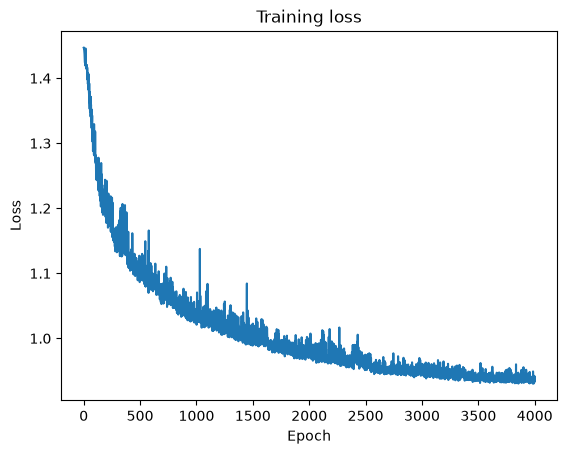

In [4]:
with open(os.path.join("logs/2026_7_6/3", 'metrics.json'), 'r') as f:
    results = json.load(f)

plt.plot(results['train_losses'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')

Text(0, 0.5, 'MAP')

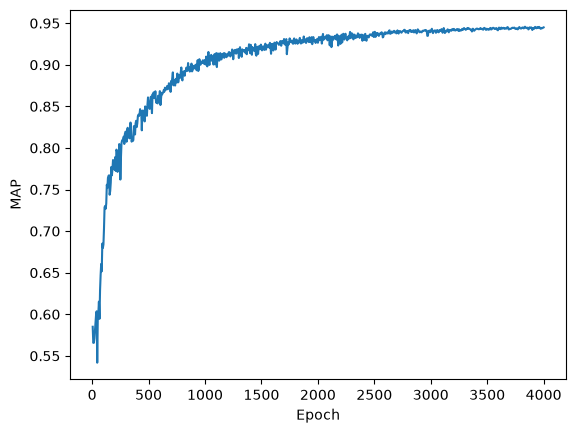

In [ ]:
epochs = [m['epoch'] for m in results['val_metrics']]
maps = [m['roc'] for m in results['val_metrics']]  # ou 'ap' selon ce que retourne compute_metrics

plt.plot(epochs, maps)
plt.xlabel('Epoch')
plt.ylabel('MAP')

Text(0.5, 0, '||z||')

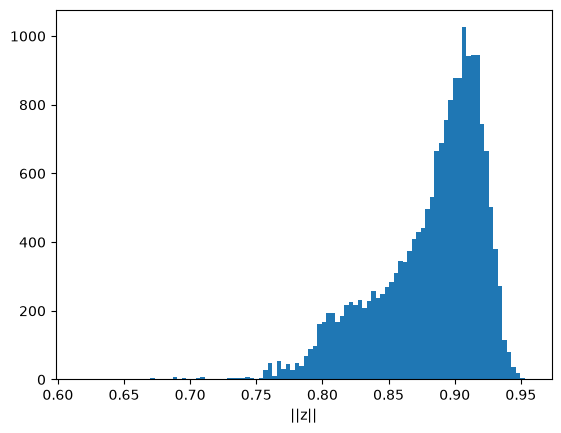

In [4]:
norms = np.linalg.norm(embeddings, axis=1)

plt.hist(norms, bins=100)
plt.xlabel('||z||')

In [ ]:
res = evaluate_embeddings(embeddings, G_hpo_work, objects_w, node2id_w, poincare.PoincareManifold())
print(res)

100%|██████████| 19389/19389 [08:23<00:00, 38.54it/s]

(0.07170529745395465, 938.2907040587912)


## Chargement des données

In [4]:
# Bases de d'annotations binaires
work_omim = work_omim.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha = work_orpha.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols0 = [c for c in work_omim.columns if c.startswith("HP:")]
# Certaines maladies ne sont encodées que sur les autres sous ontologies
work_omim = work_omim[(work_omim[hpo_cols0].sum(axis=1) != 0)] 
work_orpha = work_orpha[(work_orpha[hpo_cols0].sum(axis=1) != 0)]

df_orpha_omim_exact = df_orpha_omim[df_orpha_omim["mapping_type"]=='E (Exact mapping: the two concepts are equivalent)']
gt_set, valid_omim, valid_orpha = f_ground_truth(work_omim, work_orpha, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim.shape[0]}, ORPHA : {work_orpha.shape[0]}, paires GT : {len(gt_set)}")

Taille OMIM : 6682, ORPHA : 3189, paires GT : 2216


In [5]:
# Avec les maladies Orpha directement tirées d'Orphadata
work_omim2 = work_omim2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
work_orpha2 = work_orpha2.filter(items=['database_id'] + list(abnormality)).reset_index(drop=True)
hpo_cols2 = [c for c in work_omim2.columns if c.startswith("HP:")]

# Certaines maladies ne sont encodées que sur les autres sous ontologies
work_omim2 = work_omim2[(work_omim2[hpo_cols2].sum(axis=1) != 0)] 
work_orpha2 = work_orpha2[(work_orpha2[hpo_cols2].sum(axis=1) != 0)]

gt_set2, valid_omim2, valid_orpha2 = f_ground_truth(work_omim2, work_orpha2, df_orpha_omim_exact)
print(f"Taille OMIM : {work_omim2.shape}, ORPHA : {work_orpha2.shape}, paires GT : {len(gt_set2)}")

Taille OMIM : (6682, 11559), ORPHA : (3211, 11559), paires GT : 2236


In [9]:
# Bases de données propagées
ancestors = {hp: get_ancestors0(G_hpo_work, hp) for hp in hpo_cols0}
w_omim_P = propagate_terms(work_omim,  hpo_cols0, ancestors, depths, k=3)
w_orpha_P = propagate_terms(work_orpha, hpo_cols0, ancestors, depths, k=3)

w_omim_P2 = propagate_terms(work_omim2,  hpo_cols2, ancestors, depths, k=3)
w_orpha_P2 = propagate_terms(work_orpha2, hpo_cols2, ancestors, depths, k=3)

In [7]:
union_diseases = add_corresponding_terms(work_omim2, work_orpha2, df_orpha_omim_exact)
remaining_orpha = work_orpha2[~work_orpha2['database_id'].isin(valid_orpha2)]
print(union_diseases.shape, remaining_orpha.shape)
all_diseases = pd.concat([union_diseases, remaining_orpha])

Fusion HPO: 100%|██████████| 2236/2236 [00:00<00:00, 7213.88it/s]


(6682, 11559) (975, 11559)


## Transport optimal

### Hamming pondéré par les normes

In [11]:
C_hamm = OT.compute_cost_matrix_pseudo_jacc(
    work_omim2, work_orpha2, node2id_w, embeddings, poincare.PoincareManifold())

# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_hamm, a=None, b=None)
ranks,_, pairs, _, _ = OT.evaluate_transport(ot_plan, gt_set2, C_hamm)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_hamm)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(
    C_hamm, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = OT.evaluate_transport(ot_plan_reg, gt_set2, C_hamm)

Compute norms
Norms computed !
======== Sans régularisation ========
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.588 (1314/2236)
Top-3 accuracy : 0.617 (1380/2236)
Top-5 accuracy : 0.619 (1383/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.398 (889/2236)
Top-3 accuracy : 0.616 (1378/2236)
Top-5 accuracy : 0.618 (1381/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.398 (889/2236)
Top-3 accuracy : 0.616 (1377/2236)
Top-5 accuracy : 0.618 (1381/2236)
 Rang moyen des maladies Orpha : 620.30
 Rang moyen des maladies Omim : 942.98
======== Avec régularisation ========
7.627541805545871
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.584 (1305/2236)
Top-3 accuracy : 0.715 (1599/2236)
Top-5 accuracy : 0.764 (1709/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.542 (1212/2236)
Top-3 accuracy : 0.651 (1455/2236)
Top-5 accuracy : 0.693 (1549/2236)
=========== Lignes et Colonnes ===========
Top-1 accurac

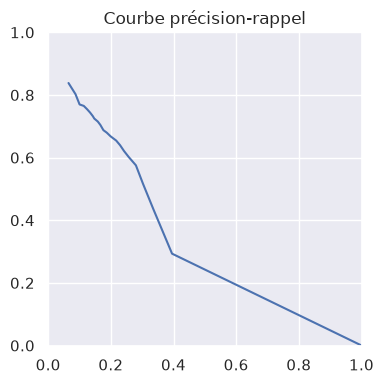

In [12]:
OT.plot_PR_curve(ot_plan_reg, gt_set2, seuils)

100%|██████████| 3/3 [01:20<00:00, 26.74s/it]


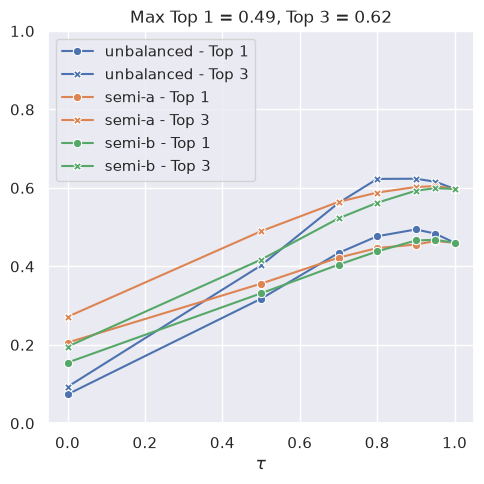

In [13]:
OT.plot_unbalanced(taus, C_hamm, epsilon, gt_set2)

### Wasserstein

In [7]:
C = OT.compute_costs_matrix_wasserstein2(
    work_omim2, work_orpha2, node2id_w, embeddings, poincare.PoincareManifold(), c=1., deprecated=deprecated
    )

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows:  18%|█▊        | 15/84 [00:23<02:10,  1.89s/it]

Distance matrix rows: 100%|██████████| 84/84 [02:13<00:00,  1.59s/it]


HPO distance matrix: (10646, 10646)


OMIM: 100%|██████████| 6682/6682 [21:26<00:00,  5.19it/s]


In [8]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C, a=None, b=None)
ranks,_, pairs, _, _ = OT.evaluate_transport(ot_plan, gt_set2, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = OT.evaluate_transport(ot_plan_reg, gt_set2, C)

dict_method={}
dict_method['wasserstein_chami']={
        "cost_matrix": C,
        "ot_plan":ot_plan_reg}
save_method(dict_method, 'wasserstein_chami')

======== Sans régularisation ========
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.378 (845/2236)
Top-3 accuracy : 0.411 (919/2236)
Top-5 accuracy : 0.412 (922/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.239 (534/2236)
Top-3 accuracy : 0.409 (914/2236)
Top-5 accuracy : 0.412 (921/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.239 (534/2236)
Top-3 accuracy : 0.408 (913/2236)
Top-5 accuracy : 0.412 (921/2236)
 Rang moyen des maladies Orpha : 952.06
 Rang moyen des maladies Omim : 1466.60
======== Avec régularisation ========
0.13567833829173137
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.407 (909/2236)
Top-3 accuracy : 0.530 (1185/2236)
Top-5 accuracy : 0.586 (1310/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.371 (830/2236)
Top-3 accuracy : 0.493 (1102/2236)
Top-5 accuracy : 0.541 (1209/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.324 (724/2236)
Top-3 accuracy :

100%|██████████| 3/3 [00:54<00:00, 18.08s/it]


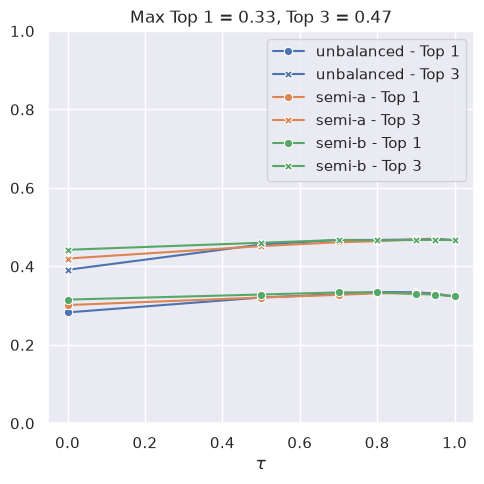

In [9]:
OT.plot_unbalanced(taus, C, epsilon, gt_set2)

### Pondération des maladies via l'*IC*

In [8]:
# Pondération des maladies
ic,_, _ = compute_information_content(all_diseases, G_hpo_work, deprecated)
ic = {t:-np.log(w) for t, w in ic.items()}

active_omim = precompute(work_omim2, node2id_w)
active_orpha = precompute(work_orpha2, node2id_w)

a_omim = precompute_weights(active_omim, ic)
b_orpha = precompute_weights(active_orpha, ic)

In [35]:
# Sans régularisation
print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C, a_omim, b_orpha)
ranks, _, pairs, _, _ = OT.evaluate_transport(ot_plan, gt_set2, C)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C, a_omim, b_orpha, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = OT.evaluate_transport(ot_plan_reg, gt_set2, C)

======== Sans régularisation ========


Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.379 (848/2236)
Top-3 accuracy : 0.408 (912/2236)
Top-5 accuracy : 0.409 (915/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.232 (518/2236)
Top-3 accuracy : 0.404 (903/2236)
Top-5 accuracy : 0.409 (914/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.232 (518/2236)
Top-3 accuracy : 0.403 (901/2236)
Top-5 accuracy : 0.409 (914/2236)
 Rang moyen des maladies Orpha : 962.93
 Rang moyen des maladies Omim : 1474.56
======== Avec régularisation ========
0.13567833829173137
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.408 (912/2236)
Top-3 accuracy : 0.527 (1178/2236)
Top-5 accuracy : 0.583 (1304/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.372 (832/2236)
Top-3 accuracy : 0.492 (1100/2236)
Top-5 accuracy : 0.536 (1199/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.325 (727/2236)
Top-3 accuracy : 0.462 (1033/2236)
Top-5 accuracy : 0.

In [10]:
C_ic = OT.compute_costs_matrix_wasserstein2(
    work_omim2, work_orpha2, node2id_w, embeddings, poincare.PoincareManifold(), c=1., deprecated=deprecated, weights=ic)

print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_ic, None, None)
ranks, _, pairs, _, _ = OT.evaluate_transport(ot_plan, gt_set2, C_ic)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_ic)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(C_ic, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = OT.evaluate_transport(ot_plan_reg, gt_set2, C_ic)

Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 84/84 [00:40<00:00,  2.08it/s]


HPO distance matrix: (10646, 10646)


OMIM: 100%|██████████| 6682/6682 [24:18<00:00,  4.58it/s]


======== Sans régularisation ========
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.378 (845/2236)
Top-3 accuracy : 0.407 (911/2236)
Top-5 accuracy : 0.409 (914/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.245 (547/2236)
Top-3 accuracy : 0.403 (902/2236)
Top-5 accuracy : 0.408 (913/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.245 (547/2236)
Top-3 accuracy : 0.403 (900/2236)
Top-5 accuracy : 0.408 (913/2236)
 Rang moyen des maladies Orpha : 952.62
 Rang moyen des maladies Omim : 1468.39
======== Avec régularisation ========
0.13844261394867233
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.409 (915/2236)
Top-3 accuracy : 0.525 (1173/2236)
Top-5 accuracy : 0.584 (1306/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.375 (839/2236)
Top-3 accuracy : 0.483 (1080/2236)
Top-5 accuracy : 0.534 (1194/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.329 (736/2236)
Top-3 accuracy :

### Barycentres

In [ ]:
C_bary = OT.compute_costs_barycenter(
    work_omim2, work_orpha2, node2id_w, embeddings, deprecated, poincare.PoincareManifold())

print("======== Sans régularisation ========")
ot_plan, ot_cost = OT.compute_transport(C_bary, None, None)
ranks, _, pairs, _, _ = OT.evaluate_transport(ot_plan, gt_set2, C_bary)

# Avec régularisation
print("======== Avec régularisation ========")
grid = np.linspace(0.01, 5, 100)
epsilon = grid[1] * np.mean(C_bary)
print(epsilon)
ot_plan_reg, ot_cots_reg = OT.compute_transport_sinkhorn(
    C_bary, None, None, epsilon, 10000, 1e-4, False)
ranks_reg, _, pairs_reg, _, _ = OT.evaluate_transport(ot_plan_reg, gt_set2, C_bary)

======== Sans régularisation ========
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.061 (136/2236)
Top-3 accuracy : 0.077 (173/2236)
Top-5 accuracy : 0.079 (177/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.036 (80/2236)
Top-3 accuracy : 0.077 (172/2236)
Top-5 accuracy : 0.078 (174/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.036 (80/2236)
Top-3 accuracy : 0.076 (171/2236)
Top-5 accuracy : 0.078 (174/2236)
 Rang moyen des maladies Orpha : 1504.56
 Rang moyen des maladies Omim : 2365.24
======== Avec régularisation ========
0.12110410252002755
Paires évaluées : 2236
=========== Lignes ===========
Top-1 accuracy : 0.076 (170/2236)
Top-3 accuracy : 0.133 (298/2236)
Top-5 accuracy : 0.173 (387/2236)
=========== Colonnes ===========
Top-1 accuracy : 0.046 (102/2236)
Top-3 accuracy : 0.097 (218/2236)
Top-5 accuracy : 0.130 (290/2236)
=========== Lignes et Colonnes ===========
Top-1 accuracy : 0.036 (81/2236)
Top-3 accuracy : 0.089

## Evaluation

In [6]:
dict_method = load_all_methods()
ot_plan_reg = dict_method['wasserstein_chami']['ot_plan']

Train : 1788
 Test : 448
Accuracy : 0.768
Precision: 0.766
Recall   : 0.768
ROC-AUC : 0.832
PR-AUC : 0.813


/opt/python/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


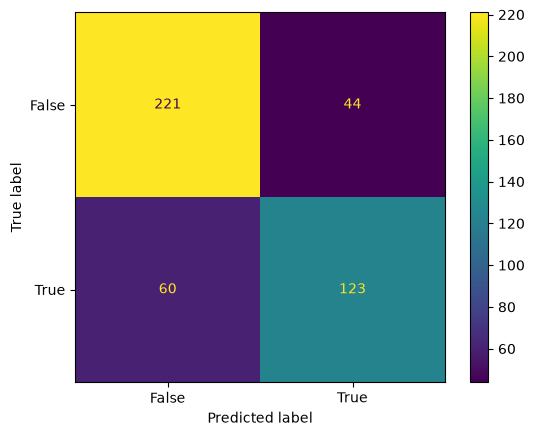

ratio_12    2.255062
top_1      -0.718714
sds         0.100066
dtype: float64
Seuil pour 90.0% précision : 0.800 (recall correspondant : 0.432)


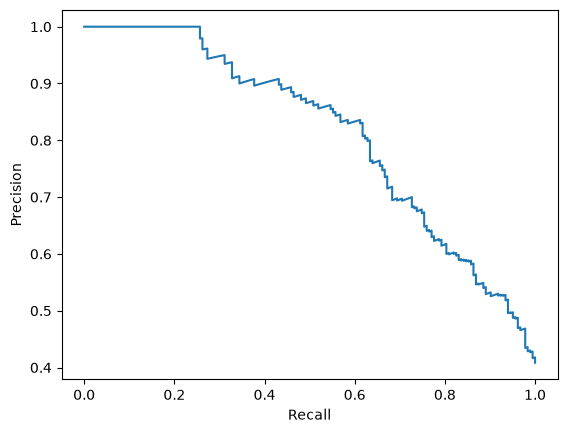

In [7]:
metrics = evaluation.logistic_reg(ot_plan_reg, gt_set2, seed=12)